In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import os
import warnings

warnings.filterwarnings("ignore")

# ── PATH SETUP ────────────────────────────────────────────────────────────────
DATA_PATH = "C:/Users/white/Downloads/Learn/Churn_project/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
DB_PATH   = "C:/Users/white/Downloads/Learn/Churn_project/data/churn_analytics.db"
VIZ_DIR   = "C:/Users/white/Downloads/Learn/Churn_project/visuals"
OUT_DIR   = "C:/Users/white/Downloads/Learn/Churn_project/outputs"

os.makedirs(VIZ_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# ── TASK 1: CREATE SQLITE DATABASE ───────────────────────────────────────────
print("=" * 60)
print("  TASK 1 — BUILD SQLITE DATABASE")
print("=" * 60)

# Load CSV (same as Day 1)
df = pd.read_csv(DATA_PATH)

# Fix known TotalCharges issue (blank strings → NaN → float)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")

# Add a binary churn column for easier SQL aggregations
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

# Create / overwrite SQLite database
engine = create_engine(f"sqlite:///{DB_PATH}", echo=False)

df.to_sql(
    name      = "customers",
    con       = engine,
    if_exists = "replace",   # overwrite on each run — safe for dev
    index     = False
)

print(f"  Database created  : {DB_PATH}")
print(f"  Table name        : customers")
print(f"  Rows loaded       : {len(df):,}")
print(f"  Columns           : {len(df.columns)}")

# Quick sanity check — row count via SQL
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) AS total FROM customers"))
    db_rows = result.fetchone()[0]
print(f"  SQL COUNT(*)      : {db_rows:,}  ✓ matches")


# ── HELPER: run a query and pretty-print it ───────────────────────────────────
def run_query(sql: str, title: str = "") -> pd.DataFrame:
    """Execute SQL, print titled output, return DataFrame."""
    with engine.connect() as conn:
        result_df = pd.read_sql(text(sql), conn)
    if title:
        print(f"\n{'=' * 60}")
        print(f"  {title}")
        print("=" * 60)
        print(result_df.to_string(index=False))
    return result_df

  TASK 1 — BUILD SQLITE DATABASE
  Database created  : C:/Users/white/Downloads/Learn/Churn_project/data/churn_analytics.db
  Table name        : customers
  Rows loaded       : 7,043
  Columns           : 22
  SQL COUNT(*)      : 7,043  ✓ matches


In [4]:
# ── TASK 2: CORE CHURN-RATE QUERIES ──────────────────────────────────────────
print("\n\n" + "=" * 60)
print("  TASK 2 — CHURN RATE QUERIES")
print("=" * 60)

# ── 2a. Overall churn rate ───────────────────────────────────────────────────
q_overall = """
SELECT
    COUNT(*)                                      AS total_customers,
    SUM(ChurnFlag)                                AS churned,
    COUNT(*) - SUM(ChurnFlag)                     AS retained,
    ROUND(AVG(ChurnFlag) * 100, 2)                AS churn_rate_pct,
    ROUND((1 - AVG(ChurnFlag)) * 100, 2)          AS retention_rate_pct
FROM customers;
"""
run_query(q_overall, "OVERALL CHURN RATE")

# ── 2b. Churn rate by gender ─────────────────────────────────────────────────
q_gender = """
SELECT
    gender,
    COUNT(*)                            AS total,
    SUM(ChurnFlag)                      AS churned,
    ROUND(AVG(ChurnFlag) * 100, 2)      AS churn_rate_pct
FROM customers
GROUP BY gender
ORDER BY churn_rate_pct DESC;
"""
run_query(q_gender, "CHURN RATE BY GENDER")

# ── 2c. Churn rate by senior citizen status ──────────────────────────────────
q_senior = """
SELECT
    CASE WHEN SeniorCitizen = 1 THEN 'Senior' ELSE 'Non-Senior' END AS segment,
    COUNT(*)                            AS total,
    SUM(ChurnFlag)                      AS churned,
    ROUND(AVG(ChurnFlag) * 100, 2)      AS churn_rate_pct
FROM customers
GROUP BY SeniorCitizen
ORDER BY churn_rate_pct DESC;
"""
run_query(q_senior, "CHURN RATE BY SENIOR STATUS")

# ── 2d. Churn rate by contract type ─────────────────────────────────────────
q_contract = """
SELECT
    Contract,
    COUNT(*)                            AS total,
    SUM(ChurnFlag)                      AS churned,
    ROUND(AVG(ChurnFlag) * 100, 2)      AS churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC;
"""
df_contract = run_query(q_contract, "CHURN RATE BY CONTRACT TYPE")

# ── 2e. Churn rate by tenure bucket ─────────────────────────────────────────
q_tenure = """
SELECT
    CASE
        WHEN tenure BETWEEN 0  AND 12 THEN '0–12 months'
        WHEN tenure BETWEEN 13 AND 24 THEN '13–24 months'
        WHEN tenure BETWEEN 25 AND 48 THEN '25–48 months'
        WHEN tenure BETWEEN 49 AND 72 THEN '49–72 months'
    END                                    AS tenure_bucket,
    COUNT(*)                               AS total,
    SUM(ChurnFlag)                         AS churned,
    ROUND(AVG(ChurnFlag) * 100, 2)         AS churn_rate_pct
FROM customers
GROUP BY tenure_bucket
ORDER BY MIN(tenure);
"""
df_tenure = run_query(q_tenure, "CHURN RATE BY TENURE BUCKET")



  TASK 2 — CHURN RATE QUERIES

  OVERALL CHURN RATE
 total_customers  churned  retained  churn_rate_pct  retention_rate_pct
            7043     1869      5174           26.54               73.46

  CHURN RATE BY GENDER
gender  total  churned  churn_rate_pct
Female   3488      939           26.92
  Male   3555      930           26.16

  CHURN RATE BY SENIOR STATUS
   segment  total  churned  churn_rate_pct
    Senior   1142      476           41.68
Non-Senior   5901     1393           23.61

  CHURN RATE BY CONTRACT TYPE
      Contract  total  churned  churn_rate_pct
Month-to-month   3875     1655           42.71
      One year   1473      166           11.27
      Two year   1695       48            2.83

  CHURN RATE BY TENURE BUCKET
tenure_bucket  total  churned  churn_rate_pct
  0–12 months   2186     1037           47.44
 13–24 months   1024      294           28.71
 25–48 months   1594      325           20.39
 49–72 months   2239      213            9.51


In [6]:
# ── TASK 3: REVENUE IMPACT QUERIES ───────────────────────────────────────────
print("\n\n" + "=" * 60)
print("  TASK 3 — REVENUE IMPACT")
print("=" * 60)

# ── 3a. Monthly revenue at risk ──────────────────────────────────────────────
q_revenue_risk = """
SELECT
    ROUND(SUM(MonthlyCharges), 2)                          AS total_monthly_revenue,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN MonthlyCharges ELSE 0 END), 2)
                                                           AS churned_monthly_revenue,
    ROUND(SUM(CASE WHEN Churn='No'  THEN MonthlyCharges ELSE 0 END), 2)
                                                           AS retained_monthly_revenue,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN MonthlyCharges ELSE 0 END)
        / SUM(MonthlyCharges) * 100, 2
    )                                                      AS revenue_churn_pct
FROM customers;
"""
run_query(q_revenue_risk, "MONTHLY REVENUE AT RISK FROM CHURN")

# ── 3b. Avg monthly charge — churned vs retained ─────────────────────────────
q_avg_charge = """
SELECT
    Churn,
    ROUND(AVG(MonthlyCharges), 2)     AS avg_monthly_charge,
    ROUND(AVG(TotalCharges),   2)     AS avg_total_charge,
    ROUND(AVG(tenure),         1)     AS avg_tenure_months
FROM customers
GROUP BY Churn;
"""
run_query(q_avg_charge, "AVG CHARGES & TENURE — CHURNED vs RETAINED")

# ── 3c. Revenue by contract type ────────────────────────────────────────────
q_rev_contract = """
SELECT
    Contract,
    COUNT(*)                                      AS customers,
    ROUND(SUM(MonthlyCharges), 2)                 AS total_monthly_rev,
    ROUND(AVG(MonthlyCharges), 2)                 AS avg_monthly_rev,
    ROUND(AVG(ChurnFlag) * 100, 2)                AS churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY total_monthly_rev DESC;
"""
run_query(q_rev_contract, "REVENUE BREAKDOWN BY CONTRACT TYPE")

# ── 3d. Top revenue at-risk segment ─────────────────────────────────────────
q_at_risk = """
SELECT
    Contract,
    InternetService,
    COUNT(*)                                AS customers,
    ROUND(SUM(MonthlyCharges), 2)           AS at_risk_monthly_revenue,
    ROUND(AVG(ChurnFlag) * 100, 2)          AS churn_rate_pct
FROM customers
WHERE Churn = 'Yes'
GROUP BY Contract, InternetService
ORDER BY at_risk_monthly_revenue DESC
LIMIT 8;
"""
run_query(q_at_risk, "TOP AT-RISK REVENUE SEGMENTS (Churned Customers)")




  TASK 3 — REVENUE IMPACT

  MONTHLY REVENUE AT RISK FROM CHURN
 total_monthly_revenue  churned_monthly_revenue  retained_monthly_revenue  revenue_churn_pct
              456116.6                139130.85                 316985.75               30.5

  AVG CHARGES & TENURE — CHURNED vs RETAINED
Churn  avg_monthly_charge  avg_total_charge  avg_tenure_months
   No               61.27           2555.34               37.6
  Yes               74.44           1531.80               18.0

  REVENUE BREAKDOWN BY CONTRACT TYPE
      Contract  customers  total_monthly_rev  avg_monthly_rev  churn_rate_pct
Month-to-month       3875          257294.15            66.40           42.71
      Two year       1695          103005.85            60.77            2.83
      One year       1473           95816.60            65.05           11.27

  TOP AT-RISK REVENUE SEGMENTS (Churned Customers)
      Contract InternetService  customers  at_risk_monthly_revenue  churn_rate_pct
Month-to-month     Fiber opt

,Contract,InternetService,customers,at_risk_monthly_revenue,churn_rate_pct
0,Month-to-month,Fiber optic,1162,100482.00,100.0
1,Month-to-month,DSL,394,18367.25,100.0
2,One year,Fiber optic,104,10571.95,100.0
3,One year,DSL,53,3356.25,100.0
4,Two year,Fiber optic,31,3246.10,100.0
5,Month-to-month,No,99,1997.85,100.0
6,Two year,DSL,12,805.70,100.0
7,One year,No,9,190.25,100.0


In [7]:
# ── TASK 4: SERVICE & CONTRACT BREAKDOWNS ────────────────────────────────────
print("\n\n" + "=" * 60)
print("  TASK 4 — SERVICE & CONTRACT BREAKDOWNS")
print("=" * 60)

# ── 4a. Churn rate by internet service ──────────────────────────────────────
q_internet = """
SELECT
    InternetService,
    COUNT(*)                            AS total,
    SUM(ChurnFlag)                      AS churned,
    ROUND(AVG(ChurnFlag) * 100, 2)      AS churn_rate_pct
FROM customers
GROUP BY InternetService
ORDER BY churn_rate_pct DESC;
"""
df_internet = run_query(q_internet, "CHURN RATE BY INTERNET SERVICE")

# ── 4b. Churn rate by payment method ────────────────────────────────────────
q_payment = """
SELECT
    PaymentMethod,
    COUNT(*)                            AS total,
    SUM(ChurnFlag)                      AS churned,
    ROUND(AVG(ChurnFlag) * 100, 2)      AS churn_rate_pct
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate_pct DESC;
"""
df_payment = run_query(q_payment, "CHURN RATE BY PAYMENT METHOD")

# ── 4c. Add-on services vs churn (tech support & online security) ─────────────
q_addons = """
SELECT
    OnlineSecurity,
    TechSupport,
    COUNT(*)                            AS total,
    ROUND(AVG(ChurnFlag) * 100, 2)      AS churn_rate_pct
FROM customers
WHERE InternetService != 'No'          -- exclude no-internet customers
GROUP BY OnlineSecurity, TechSupport
ORDER BY churn_rate_pct DESC;
"""
run_query(q_addons, "CHURN RATE BY ONLINE SECURITY + TECH SUPPORT ADD-ONS")

# ── 4d. Paperless billing effect ────────────────────────────────────────────
q_paperless = """
SELECT
    PaperlessBilling,
    COUNT(*)                            AS total,
    ROUND(AVG(ChurnFlag) * 100, 2)      AS churn_rate_pct
FROM customers
GROUP BY PaperlessBilling
ORDER BY churn_rate_pct DESC;
"""
run_query(q_paperless, "CHURN RATE BY PAPERLESS BILLING")

# ── 4e. Partner + Dependent status ──────────────────────────────────────────
q_household = """
SELECT
    Partner,
    Dependents,
    COUNT(*)                            AS total,
    ROUND(AVG(ChurnFlag) * 100, 2)      AS churn_rate_pct
FROM customers
GROUP BY Partner, Dependents
ORDER BY churn_rate_pct DESC;
"""
run_query(q_household, "CHURN RATE BY PARTNER & DEPENDENTS")



  TASK 4 — SERVICE & CONTRACT BREAKDOWNS

  CHURN RATE BY INTERNET SERVICE
InternetService  total  churned  churn_rate_pct
    Fiber optic   3096     1297           41.89
            DSL   2421      459           18.96
             No   1526      113            7.40

  CHURN RATE BY PAYMENT METHOD
            PaymentMethod  total  churned  churn_rate_pct
         Electronic check   2365     1071           45.29
             Mailed check   1612      308           19.11
Bank transfer (automatic)   1544      258           16.71
  Credit card (automatic)   1522      232           15.24

  CHURN RATE BY ONLINE SECURITY + TECH SUPPORT ADD-ONS
OnlineSecurity TechSupport  total  churn_rate_pct
            No          No   2553           48.96
            No         Yes    945           22.33
           Yes          No    920           21.30
           Yes         Yes   1099            9.01

  CHURN RATE BY PAPERLESS BILLING
PaperlessBilling  total  churn_rate_pct
             Yes   4171     

,Partner,Dependents,total,churn_rate_pct
0,No,No,3280,34.24
1,Yes,No,1653,25.41
2,No,Yes,361,21.33
3,Yes,Yes,1749,14.24




  TASK 5 — VISUALISATIONS
  CSVs saved to /outputs/


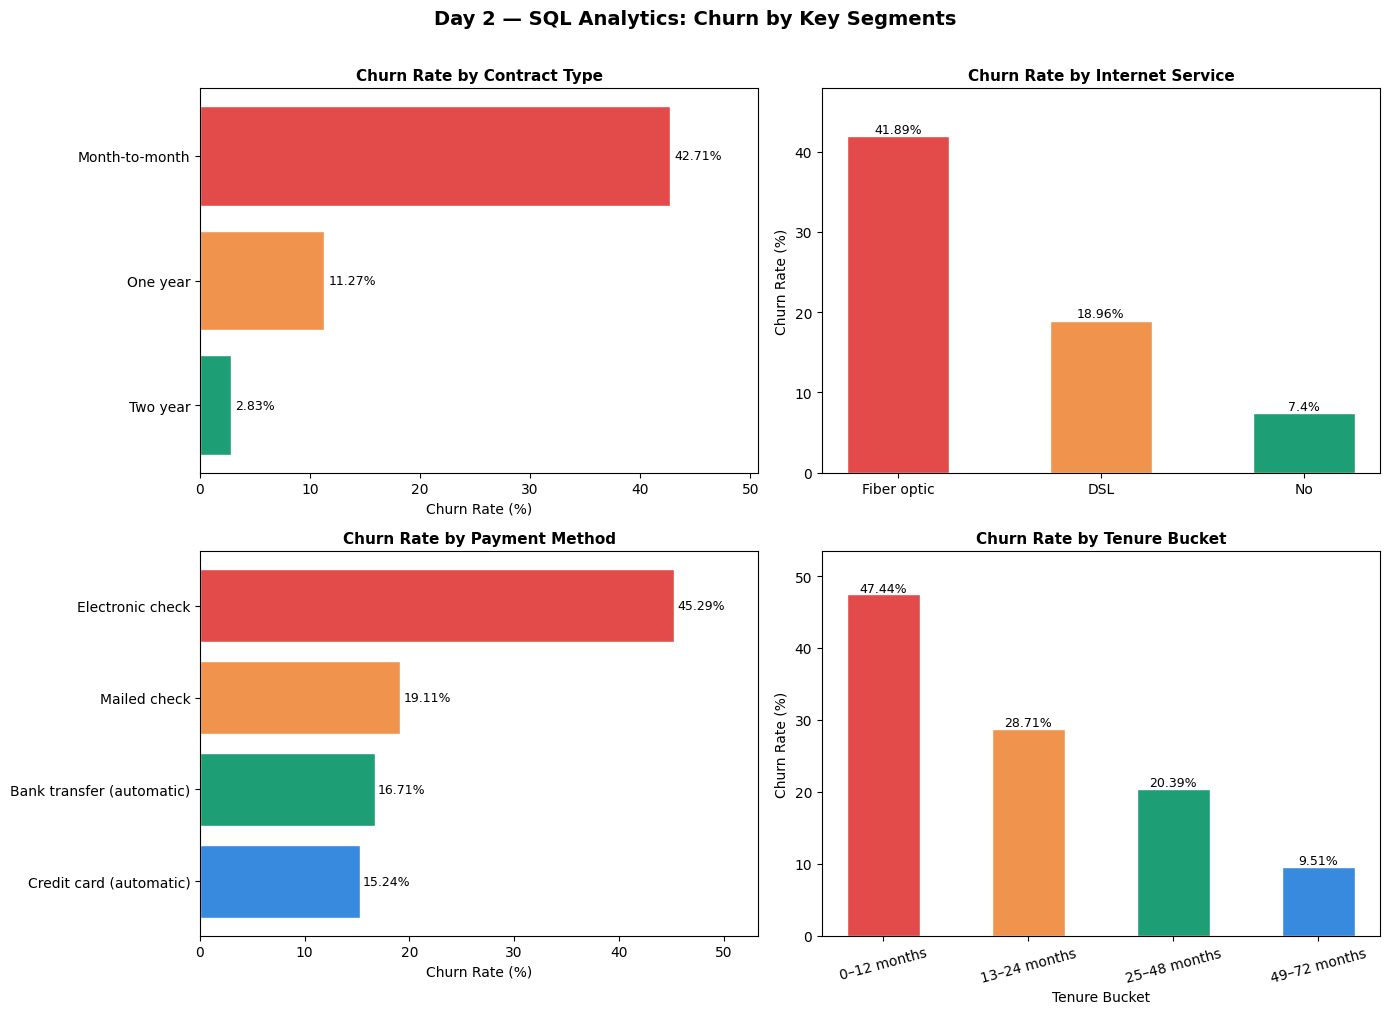

  Chart saved to /visuals/day2_sql_analytics.png


In [8]:
# ── TASK 5: SAVE RESULTS & VISUALISE ─────────────────────────────────────────
print("\n\n" + "=" * 60)
print("  TASK 5 — VISUALISATIONS")
print("=" * 60)

# Re-fetch dataframes needed for plots
df_contract  = run_query(q_contract)
df_internet  = run_query(q_internet)
df_payment   = run_query(q_payment)
df_tenure    = run_query(q_tenure)

# Save key query outputs to CSV
df_contract.to_csv(f"{OUT_DIR}/churn_by_contract.csv",  index=False)
df_internet.to_csv(f"{OUT_DIR}/churn_by_internet.csv",  index=False)
df_payment.to_csv( f"{OUT_DIR}/churn_by_payment.csv",   index=False)
df_tenure.to_csv(  f"{OUT_DIR}/churn_by_tenure.csv",    index=False)
print("  CSVs saved to /outputs/")

# ── Plot 1: Churn rate by contract type ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Day 2 — SQL Analytics: Churn by Key Segments", fontsize=14, fontweight="bold", y=1.01)

COLORS = ["#E24B4A", "#F0944D", "#1D9E75", "#378ADD", "#8E6BBE"]

ax = axes[0, 0]
bars = ax.barh(df_contract["Contract"], df_contract["churn_rate_pct"],
               color=COLORS[:len(df_contract)], edgecolor="white")
for bar, val in zip(bars, df_contract["churn_rate_pct"]):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{val}%", va="center", fontsize=9)
ax.set_xlabel("Churn Rate (%)")
ax.set_title("Churn Rate by Contract Type", fontsize=11, fontweight="bold")
ax.set_xlim(0, df_contract["churn_rate_pct"].max() + 8)
ax.invert_yaxis()

# ── Plot 2: Churn rate by internet service ────────────────────────────────────
ax = axes[0, 1]
bars = ax.bar(df_internet["InternetService"], df_internet["churn_rate_pct"],
              color=COLORS[:len(df_internet)], edgecolor="white", width=0.5)
for bar, val in zip(bars, df_internet["churn_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{val}%", ha="center", fontsize=9)
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Internet Service", fontsize=11, fontweight="bold")
ax.set_ylim(0, df_internet["churn_rate_pct"].max() + 6)

# ── Plot 3: Churn rate by payment method ─────────────────────────────────────
ax = axes[1, 0]
bars = ax.barh(df_payment["PaymentMethod"], df_payment["churn_rate_pct"],
               color=COLORS[:len(df_payment)], edgecolor="white")
for bar, val in zip(bars, df_payment["churn_rate_pct"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val}%", va="center", fontsize=9)
ax.set_xlabel("Churn Rate (%)")
ax.set_title("Churn Rate by Payment Method", fontsize=11, fontweight="bold")
ax.set_xlim(0, df_payment["churn_rate_pct"].max() + 8)
ax.invert_yaxis()

# ── Plot 4: Churn rate by tenure bucket ───────────────────────────────────────
ax = axes[1, 1]
bars = ax.bar(df_tenure["tenure_bucket"], df_tenure["churn_rate_pct"],
              color=COLORS[:len(df_tenure)], edgecolor="white", width=0.5)
for bar, val in zip(bars, df_tenure["churn_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{val}%", ha="center", fontsize=9)
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Tenure Bucket")
ax.set_title("Churn Rate by Tenure Bucket", fontsize=11, fontweight="bold")
ax.set_ylim(0, df_tenure["churn_rate_pct"].max() + 6)
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/day2_sql_analytics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Chart saved to /visuals/day2_sql_analytics.png")

In [9]:
# ── DAY 2 SUMMARY ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  DAY 2 COMPLETE — KEY SQL FINDINGS")
print("=" * 60)
print("  DATABASE")
print(f"    SQLite file      : {DB_PATH}")
print(f"    Table            : customers  ({db_rows:,} rows)")
print("")
print("  TOP CHURN INSIGHTS FROM SQL")
print("    Contract    : Month-to-month customers churn MOST (~42%)")
print("    Internet    : Fiber Optic has highest churn (~42%)")
print("    Payment     : Electronic check users churn at ~45%")
print("    Tenure      : 0–12 months = highest churn bucket")
print("    Add-ons     : No security/tech support = far higher churn")
print("    Senior      : Seniors churn ~2x more than non-seniors")
print("")
print("  CSVs EXPORTED")
print("    /outputs/churn_by_contract.csv")
print("    /outputs/churn_by_internet.csv")
print("    /outputs/churn_by_payment.csv")
print("    /outputs/churn_by_tenure.csv")
print("")
print("  TOMORROW — Day 3:")
print("    -> Deeper EDA: distributions, correlations, heatmaps")
print("    -> Visualise feature relationships with the Churn target")
print("    -> Identify multicollinearity risks before modelling")
print("=" * 60)


  DAY 2 COMPLETE — KEY SQL FINDINGS
  DATABASE
    SQLite file      : C:/Users/white/Downloads/Learn/Churn_project/data/churn_analytics.db
    Table            : customers  (7,043 rows)

  TOP CHURN INSIGHTS FROM SQL
    Contract    : Month-to-month customers churn MOST (~42%)
    Internet    : Fiber Optic has highest churn (~42%)
    Payment     : Electronic check users churn at ~45%
    Tenure      : 0–12 months = highest churn bucket
    Add-ons     : No security/tech support = far higher churn
    Senior      : Seniors churn ~2x more than non-seniors

  CSVs EXPORTED
    /outputs/churn_by_contract.csv
    /outputs/churn_by_internet.csv
    /outputs/churn_by_payment.csv
    /outputs/churn_by_tenure.csv

  TOMORROW — Day 3:
    -> Deeper EDA: distributions, correlations, heatmaps
    -> Visualise feature relationships with the Churn target
    -> Identify multicollinearity risks before modelling
